
PART A

Gowtham S - 24BAD028
Number of Training Images: 60000
Image Dimensions: (28, 28)
Original Data Shape: (60000, 28, 28)


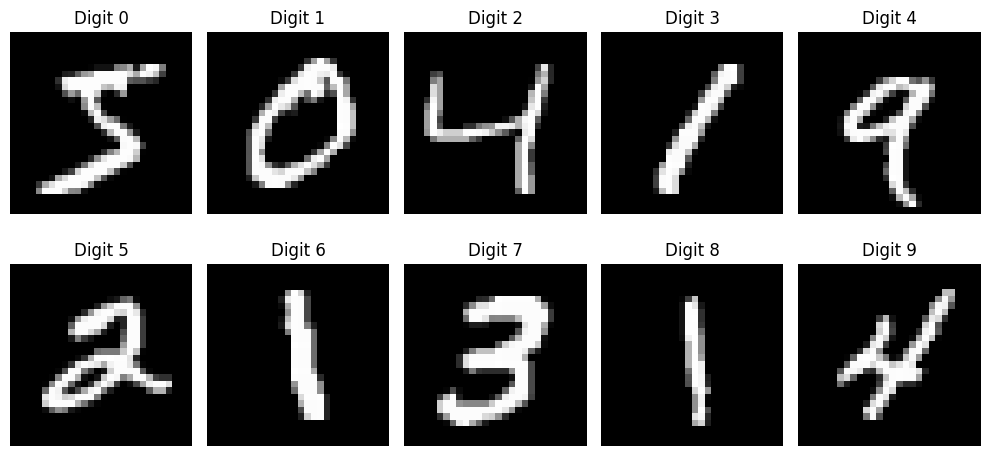

In [ ]:
#Dataset Preparation and Image Preprocessing

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Gowtham S - 24BAD028")

(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Number of Training Images:", x_train.shape[0])
print("Image Dimensions:", x_train.shape[1:])
print("Original Data Shape:", x_train.shape)

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

x_train = np.expand_dims(x_train, axis=-1)

print("Preprocessed Data Shape:", x_train.shape)
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)

train_dataset = train_dataset.shuffle(BUFFER_SIZE)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Batch Size:", BATCH_SIZE)
print("Dataset pipeline created successfully")

Preprocessed Data Shape: (60000, 28, 28, 1)
Minimum Pixel Value: -1.0
Maximum Pixel Value: 1.0
Batch Size: 256
Dataset pipeline created successfully


PART B

Gowtham S - 24BAD028
GENERATOR MODEL


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Generated Image Shape: (1, 28, 28, 1)


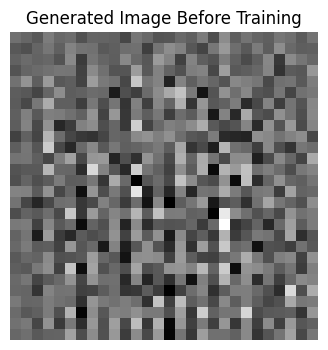

In [ ]:
#Implementing the Generator

print("Gowtham S - 24BAD028")

LATENT_DIM = 100

generator = tf.keras.Sequential([
    tf.keras.layers.Dense(
        7 * 7 * 256,
        use_bias=False,
        input_shape=(LATENT_DIM,)
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Reshape((7, 7, 256)),

    tf.keras.layers.Conv2DTranspose(
        128,
        (5, 5),
        strides=(1, 1),
        padding="same",
        use_bias=False
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        64,
        (5, 5),
        strides=(2, 2),
        padding="same",
        use_bias=False
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        1,
        (5, 5),
        strides=(2, 2),
        padding="same",
        use_bias=False,
        activation="tanh"
    )
])

print("GENERATOR MODEL")
generator.summary()

noise = tf.random.normal([1, LATENT_DIM])

generated_image = generator(
    noise,
    training=False
)

print("Generated Image Shape:", generated_image.shape)

plt.figure(figsize=(4, 4))

plt.imshow(
    (generated_image[0, :, :, 0] + 1) / 2,
    cmap="gray"
)

plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()

PART C

In [ ]:
#Implementing the Discriminator and GAN Model

print("Gowtham S - 24BAD028")

discriminator = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        64,
        (5, 5),
        strides=(2, 2),
        padding="same",
        input_shape=(28, 28, 1)
    ),

    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(
        128,
        (5, 5),
        strides=(2, 2),
        padding="same"
    ),

    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(1)
])

print("DISCRIMINATOR MODEL")

discriminator.summary()

cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss


def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

noise = tf.random.normal([1, 100])

generated_image = generator(
    noise,
    training=False
)

discriminator_output = discriminator(
    generated_image,
    training=False
)

print("Generated Image Shape:", generated_image.shape)

print("Discriminator Output Shape:",
      discriminator_output.shape)

print("GAN model created successfully")

Gowtham S - 24BAD028
DISCRIMINATOR MODEL


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Generated Image Shape: (1, 28, 28, 1)
Discriminator Output Shape: (1, 1)
GAN model created successfully


PART D

Epoch 1/30 - Generator Loss: 0.6294 - Discriminator Loss: 1.2733


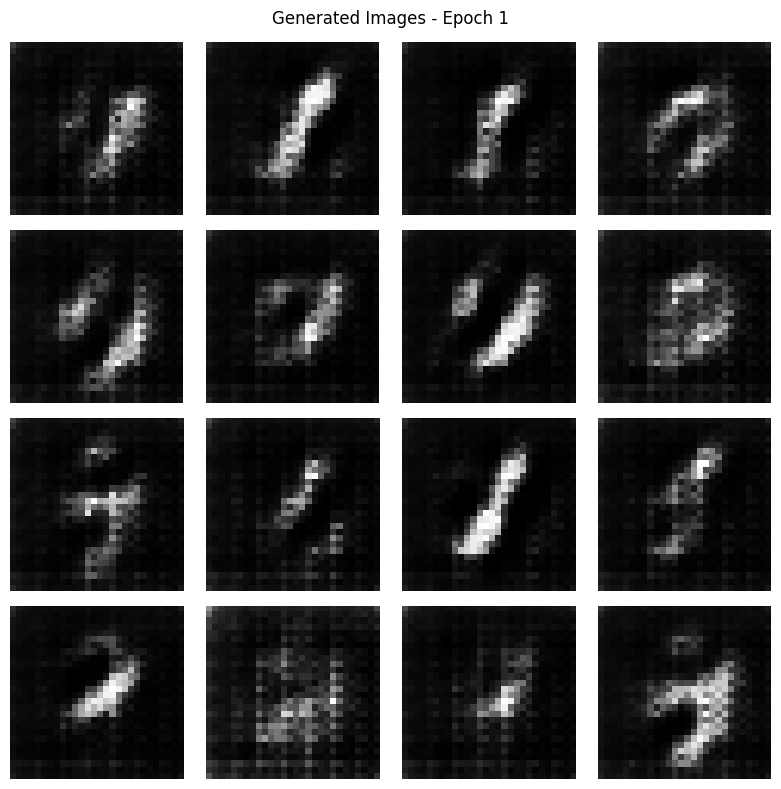

Epoch 2/30 - Generator Loss: 0.7358 - Discriminator Loss: 1.3034
Epoch 3/30 - Generator Loss: 0.7415 - Discriminator Loss: 1.3298
Epoch 4/30 - Generator Loss: 0.7423 - Discriminator Loss: 1.3336
Epoch 5/30 - Generator Loss: 0.7588 - Discriminator Loss: 1.3240


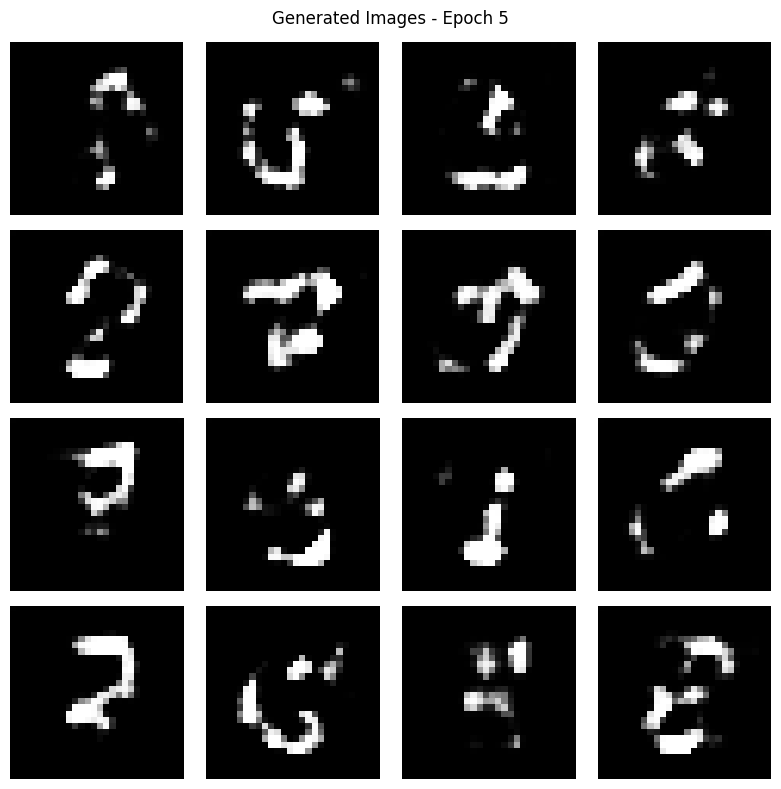

Epoch 6/30 - Generator Loss: 0.7711 - Discriminator Loss: 1.3045
Epoch 7/30 - Generator Loss: 0.8008 - Discriminator Loss: 1.2850
Epoch 8/30 - Generator Loss: 0.7880 - Discriminator Loss: 1.3001
Epoch 9/30 - Generator Loss: 0.7636 - Discriminator Loss: 1.3275
Epoch 10/30 - Generator Loss: 0.7532 - Discriminator Loss: 1.3396


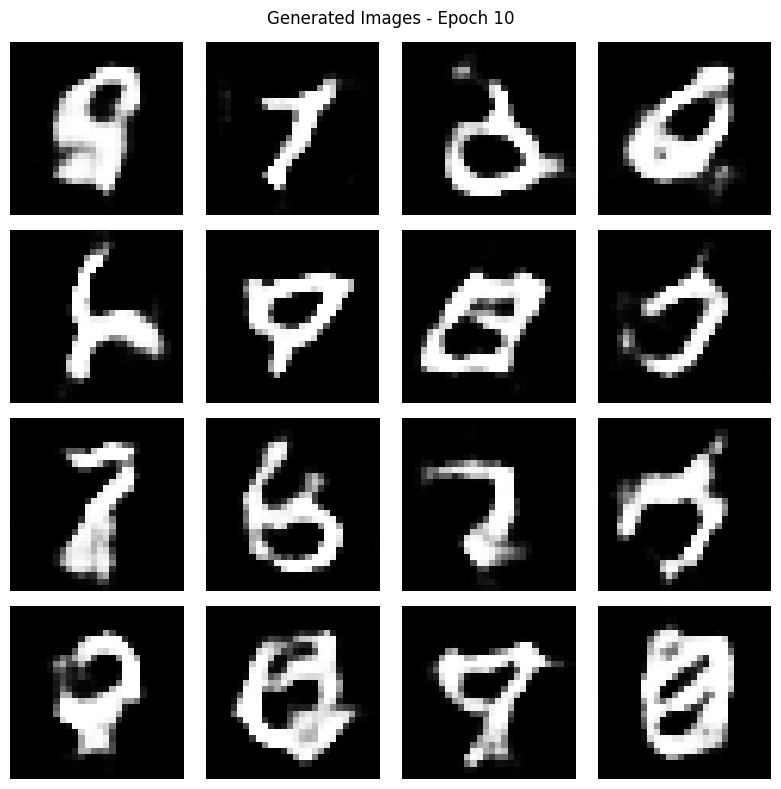

Epoch 11/30 - Generator Loss: 0.7467 - Discriminator Loss: 1.3447
Epoch 12/30 - Generator Loss: 0.7414 - Discriminator Loss: 1.3491
Epoch 13/30 - Generator Loss: 0.7523 - Discriminator Loss: 1.3453
Epoch 14/30 - Generator Loss: 0.7469 - Discriminator Loss: 1.3438
Epoch 15/30 - Generator Loss: 0.7382 - Discriminator Loss: 1.3491


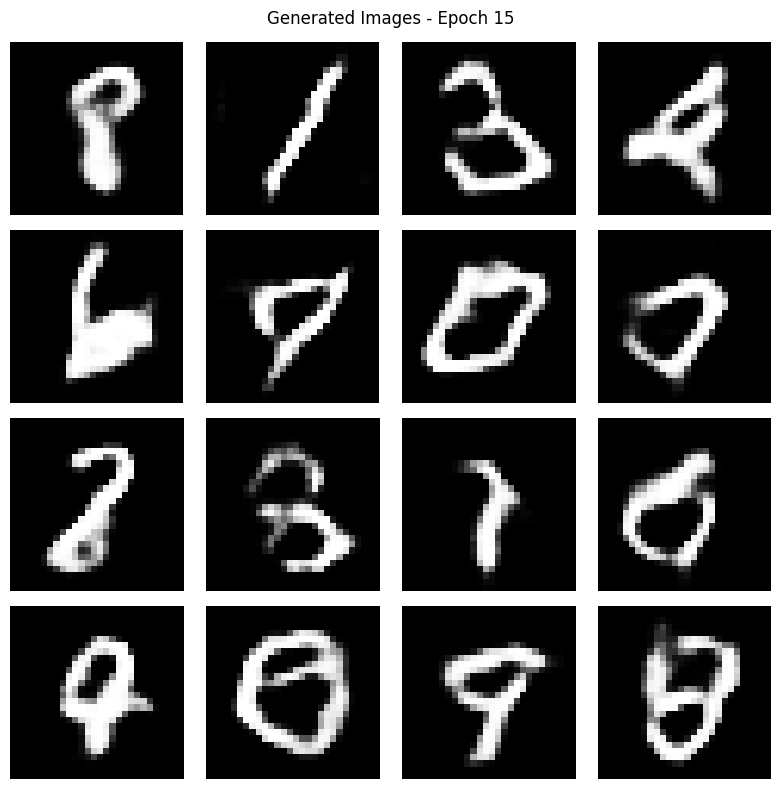

Epoch 16/30 - Generator Loss: 0.7452 - Discriminator Loss: 1.3469
Epoch 17/30 - Generator Loss: 0.7519 - Discriminator Loss: 1.3414
Epoch 18/30 - Generator Loss: 0.7410 - Discriminator Loss: 1.3448
Epoch 19/30 - Generator Loss: 0.7400 - Discriminator Loss: 1.3462
Epoch 20/30 - Generator Loss: 0.7606 - Discriminator Loss: 1.3375


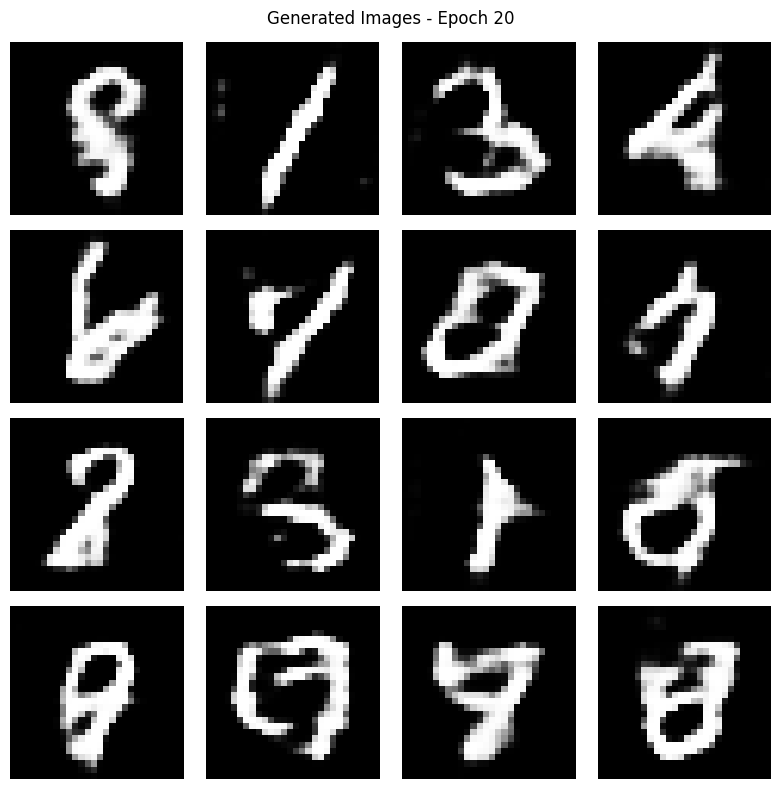

Epoch 21/30 - Generator Loss: 0.7497 - Discriminator Loss: 1.3392
Epoch 22/30 - Generator Loss: 0.7434 - Discriminator Loss: 1.3419
Epoch 23/30 - Generator Loss: 0.7428 - Discriminator Loss: 1.3427
Epoch 24/30 - Generator Loss: 0.7674 - Discriminator Loss: 1.3320
Epoch 25/30 - Generator Loss: 0.7579 - Discriminator Loss: 1.3323


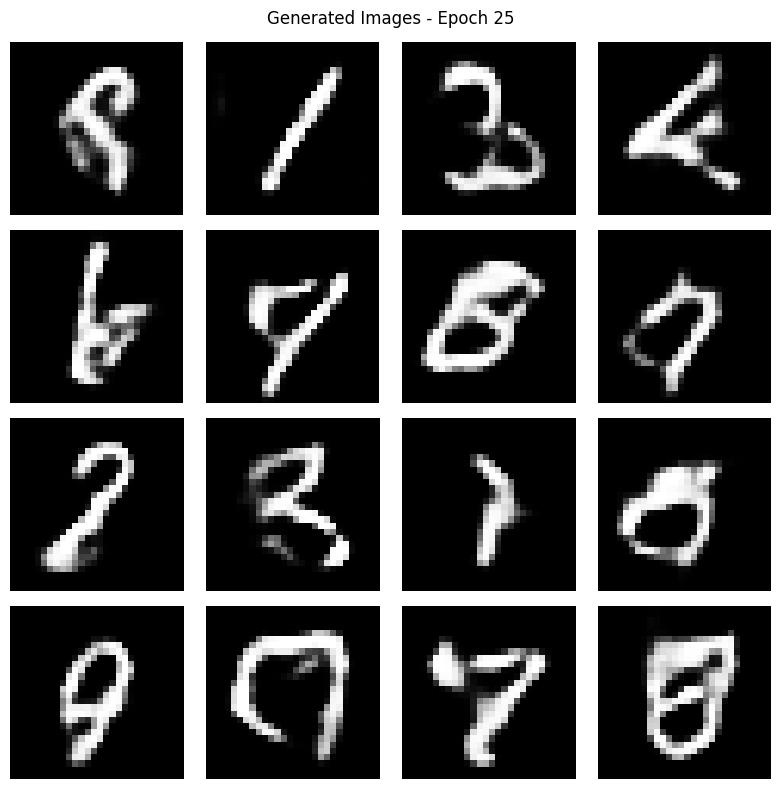

Epoch 26/30 - Generator Loss: 0.7456 - Discriminator Loss: 1.3401
Epoch 27/30 - Generator Loss: 0.7636 - Discriminator Loss: 1.3330
Epoch 28/30 - Generator Loss: 0.7543 - Discriminator Loss: 1.3328
Epoch 29/30 - Generator Loss: 0.7706 - Discriminator Loss: 1.3299
Epoch 30/30 - Generator Loss: 0.7598 - Discriminator Loss: 1.3314


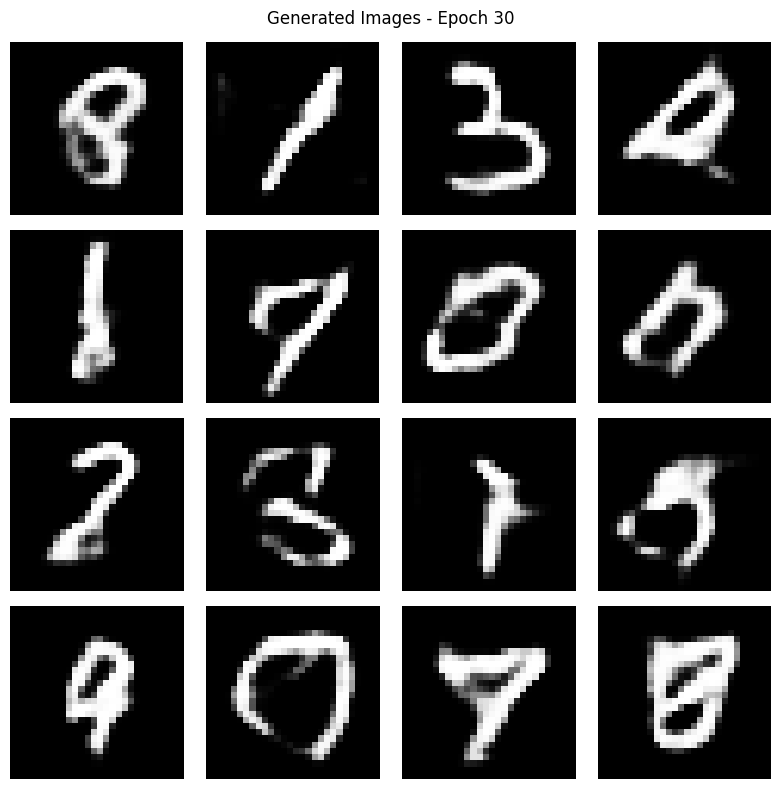

GAN training completed successfully


In [ ]:
#GAN Training and Synthetic Image Generation

import os

EPOCHS = 30

LATENT_DIM = 100

NUM_EXAMPLES_TO_GENERATE = 16

generator_losses = []

discriminator_losses = []

seed = tf.random.normal(
    [NUM_EXAMPLES_TO_GENERATE, LATENT_DIM]
)

os.makedirs("gan_results", exist_ok=True)


@tf.function
def train_step(images):

    noise = tf.random.normal(
        [256, LATENT_DIM]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


def generate_and_save_images(
    model,
    epoch,
    test_input
):

    predictions = model(
        test_input,
        training=False
    )

    plt.figure(figsize=(8, 8))

    for i in range(
        predictions.shape[0]
    ):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (predictions[i, :, :, 0] + 1) / 2,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Images - Epoch {epoch}"
    )

    plt.tight_layout()

    filename = (
        f"gan_results/"
        f"image_at_epoch_{epoch:03d}.png"
    )

    plt.savefig(
        filename,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_generator_losses = []

    epoch_discriminator_losses = []

    for image_batch in train_dataset:

        current_batch_size = tf.shape(
            image_batch
        )[0]

        if current_batch_size != 256:
            continue

        gen_loss, disc_loss = train_step(
            image_batch
        )

        epoch_generator_losses.append(
            float(gen_loss)
        )

        epoch_discriminator_losses.append(
            float(disc_loss)
        )

    average_generator_loss = np.mean(
        epoch_generator_losses
    )

    average_discriminator_loss = np.mean(
        epoch_discriminator_losses
    )

    generator_losses.append(
        average_generator_loss
    )

    discriminator_losses.append(
        average_discriminator_loss
    )

    print(
        f"Epoch {epoch}/{EPOCHS} "
        f"- Generator Loss: "
        f"{average_generator_loss:.4f} "
        f"- Discriminator Loss: "
        f"{average_discriminator_loss:.4f}"
    )

    if epoch == 1 or epoch % 5 == 0:

        generate_and_save_images(
            generator,
            epoch,
            seed
        )


print("GAN training completed successfully")

    Epoch  Generator Loss  Discriminator Loss
0       1        0.629388            1.273309
1       2        0.735777            1.303425
2       3        0.741490            1.329775
3       4        0.742299            1.333574
4       5        0.758843            1.324042
5       6        0.771108            1.304531
6       7        0.800759            1.284963
7       8        0.787982            1.300111
8       9        0.763639            1.327465
9      10        0.753166            1.339612
10     11        0.746737            1.344692
11     12        0.741408            1.349133
12     13        0.752280            1.345282
13     14        0.746923            1.343772
14     15        0.738220            1.349125
15     16        0.745191            1.346882
16     17        0.751863            1.341377
17     18        0.741014            1.344844
18     19        0.739988            1.346191
19     20        0.760627            1.337525
20     21        0.749672         

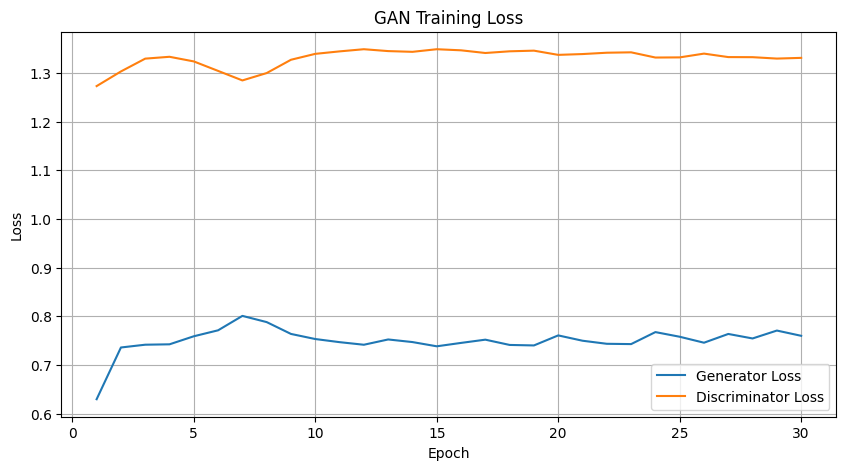

In [ ]:
#Loss Graph

loss_data = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Generator Loss": generator_losses,
    "Discriminator Loss": discriminator_losses
})

print(loss_data)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("GAN Training Loss")

plt.legend()

plt.grid(True)

plt.show()

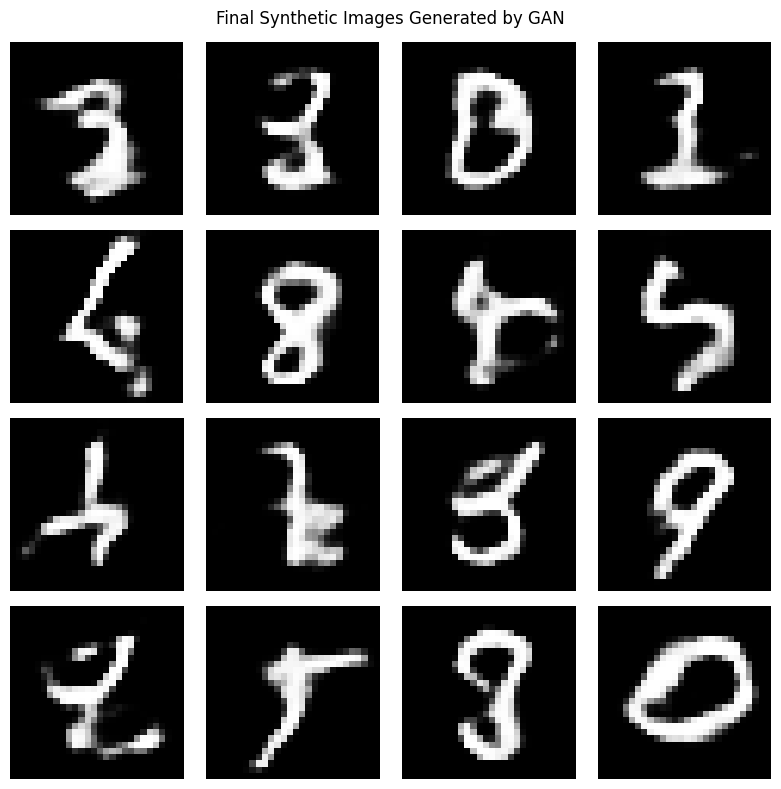

In [ ]:
#Real vs Generated Images

final_noise = tf.random.normal(
    [16, LATENT_DIM]
)

final_images = generator(
    final_noise,
    training=False
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        (final_images[i, :, :, 0] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Synthetic Images Generated by GAN"
)

plt.tight_layout()

plt.show()

Gowtham S - 24BAD028


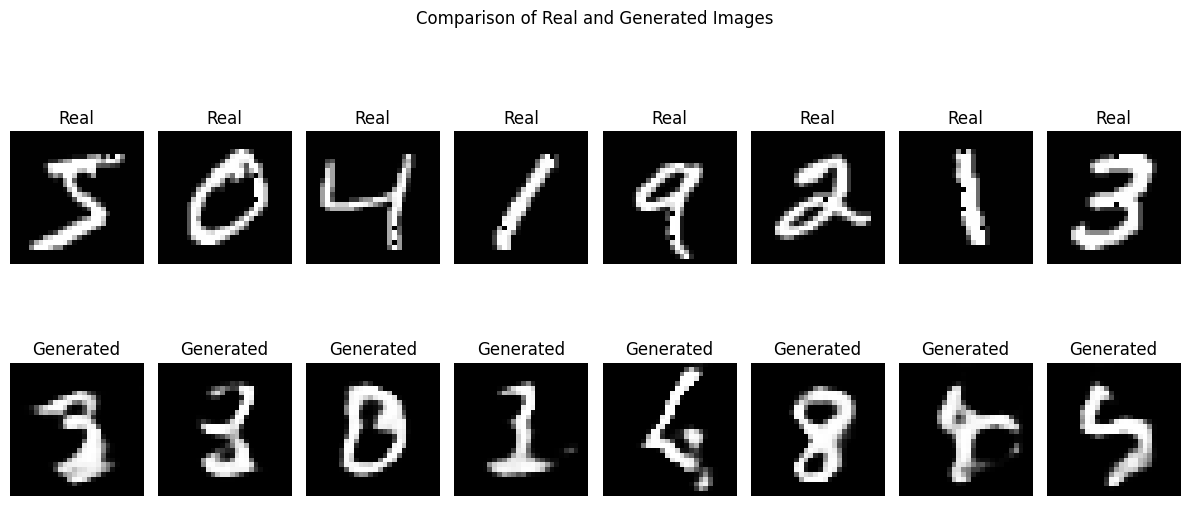

In [ ]:
print("Gowtham S - 24BAD028")

plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 8, i + 1)

    img_to_show = np.squeeze(x_train[i])
    plt.imshow(
        (img_to_show + 1) / 2,
        cmap="gray"
    )
    plt.title("Real")
    plt.axis("off")

for i in range(8):
    plt.subplot(2, 8, i + 9)
    plt.imshow(
        (final_images[i, :, :, 0] + 1) / 2,
        cmap="gray"
    )
    plt.title("Generated")
    plt.axis("off")

plt.suptitle(
    "Comparison of Real and Generated Images"
)
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

os.makedirs(
    "gan_results/final_images",
    exist_ok=True
)

for i in range(16):

    image = (
        (final_images[i, :, :, 0].numpy() + 1)
        * 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype(np.uint8)

    Image.fromarray(
        image
    ).save(
        f"gan_results/final_images/"
        f"generated_{i + 1}.png"
    )

print(
    "16 final generated images saved successfully."
)

16 final generated images saved successfully.
